## 01 - Signal Processing & Bounce Detection

This notebook implements the **signal processing pipeline** described in the paper:
> **Sound-Based Spin Estimation in Table Tennis: Dataset and Real-Time Classification Pipeline**[1]
>
> Thomas Gossard, Julian Schmalzl, Andreas Ziegler, Andreas Zell

In this notebook we focus on
1. **Audio signal exploration** - Loading and visualizing the raw recordings
2. **High-Pass filtering** - isolating bounce-characteristic frequencies (>10 kHz)
3. **Energy-based bounce detection** - exponential moving average peak detection
4. **Exploring other bounce detection** - comparing alternative approaches such as thresholding, envelope analysis, and spectral-based detection
5. **Bounce extraction** - extracting 15 ms clips from detected events
6. **Feature extraction** - Mel spectrograms, MFCCs, frequency spectra
7. **Comparative analysis** — differences across surface types and spin types
8. **t-SNE visualization** — embedding spectrograms in 2D space

In [1]:
import sys
sys.path.insert(0, '..')

import src.audio_utils as audio_utils
import src.plots as plots

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd


plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
plt.style.use("dark_background")
DATA_DIR = '../data'
SOUNDS_DIR = f'{DATA_DIR}/sounds'
RAW_DIR = f'{DATA_DIR}/raw_sounds'
SR = 44100

## Data overview
The dataset contains 5702 racket annotated bounces across 10 racket configuration + table, floor

In [2]:
df = pd.read_csv(f"{DATA_DIR}/full.csv")

print(f"Total Samples : {len(df)}")
print(f"\nColumns: {list(df.columns)}")
df.head(10)

Total Samples : 5702

Columns: ['bounce-id', 'original-file', 'timestamp', 'surface', 'racket-type', 'spin-magnitude', 'spin-direction']


,bounce-id,original-file,timestamp,surface,racket-type,spin-magnitude,spin-direction
0,0,STE-011.wav,1.078,table,none,none,none
1,1,STE-011.wav,1.636,table,none,none,none
2,2,STE-011.wav,2.134,table,none,none,none
3,3,STE-011.wav,2.587,table,none,none,none
4,4,STE-011.wav,3.002,table,none,none,none
5,5,STE-011.wav,3.385,table,none,none,none
6,6,STE-011.wav,3.735,table,none,none,none
7,7,STE-011.wav,4.062,table,none,none,none
8,8,STE-011.wav,4.366,table,none,none,none
9,9,STE-011.wav,4.651,table,none,none,none


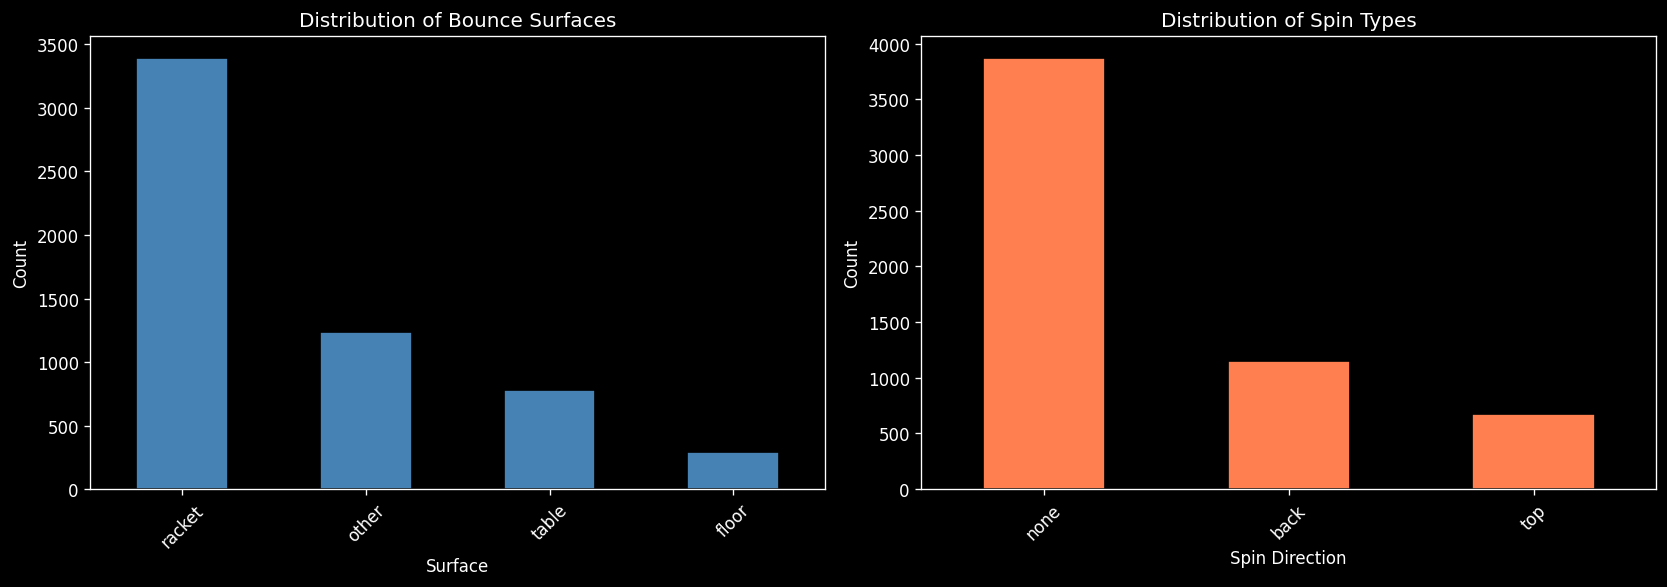

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Surface distribution
surface_counts = df['surface'].value_counts()
surface_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Bounce Surfaces')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Surface')
axes[0].tick_params(axis='x', rotation=45)

# Spin distribution (only where spin is annotated)
spin_counts = df['spin-direction'].value_counts()
spin_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Distribution of Spin Types')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Spin Direction')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 1. Exploring raw audio recording

Raw files are for example the entire recording of a match

In [4]:
import os

# List available raw recordings
raw_files = sorted(os.listdir(RAW_DIR))
print(f"Number of raw recordings: {len(raw_files)}")
print(f"\nFirst 20 files:")
for f in raw_files[:5]:
    print(f"  {f}")

Number of raw recordings: 149

First 20 files:
  01-back_less.wav
  01-back_more.wav
  01-top_less.wav
  01-top_more.wav
  01.wav


In [5]:
# Load a raw recording with table bounces (STE-011 contains table bounces)
def get_random_raw():
    import random
    from pathlib import Path
    files = list(Path(RAW_DIR).glob("*.wav"))
    if not files:
        return None

    return random.choice(files)
#raw_file = get_random_raw()

raw_file = os.path.join(RAW_DIR, 'STE-012.wav')
sig, sr = audio_utils.open_audio(raw_file)
waveform = sig.squeeze().numpy()

print(f"File name: {raw_file}")
print(f"Sample rate: {sr} Hz")
print(f"Sample length: {len(waveform)}")
print(f"Duration: {len(waveform)/sr:.2f} s")
print(f"Peak amplitude: {np.max(np.abs(waveform)):.4f}")

File name: ../data/raw_sounds/STE-012.wav
Sample rate: 44100 Hz
Sample length: 392000
Duration: 8.89 s
Peak amplitude: 1.0000


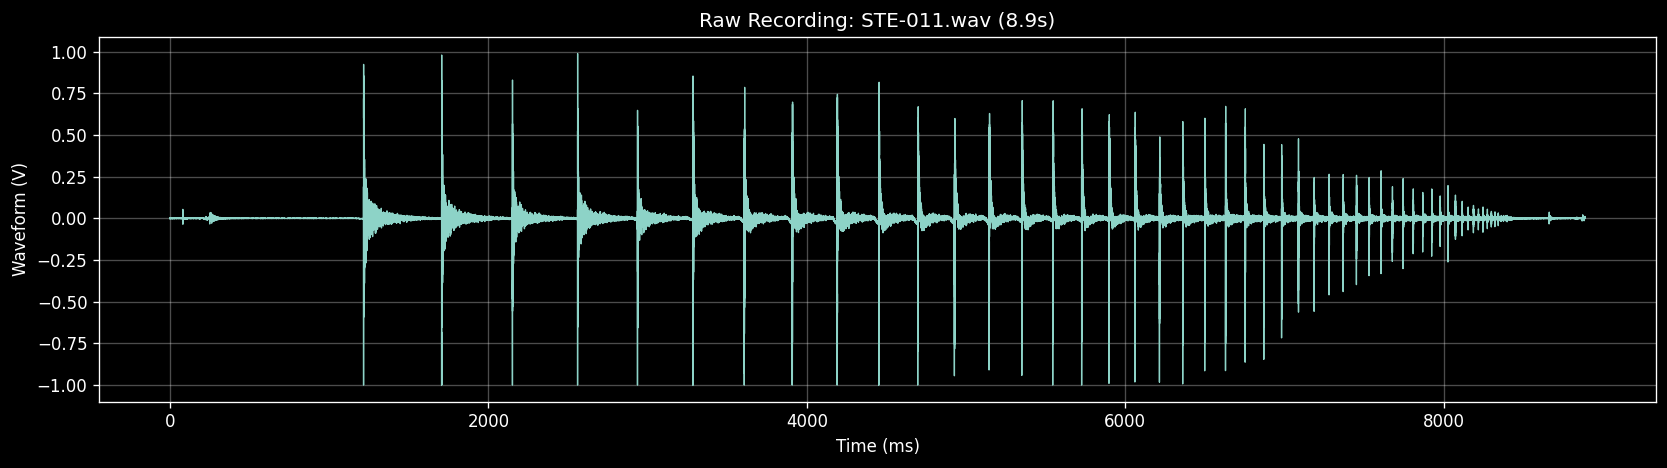

In [8]:
# Full waveform view
fig, ax = plt.subplots(figsize=(14, 4))
plots.plot_waveform_ms(waveform, sr, title=f"Raw Recording: STE-011.wav ({len(waveform)/sr:.1f}s)", ax=ax)
plt.tight_layout()
plt.show()

# Listen to a short segment
display(ipd.Audio(waveform, rate=sr))

## 2. High-Pass Filtering
Table tennis ball bounces exhibit energy predominantly around **11 kHz and above**. The paper[1] applies a **5th-order Butterworth high-pass filter** at **10 kHz** to:
- Suppress low-frequency ambient noise (speech, room acoustics)
- Isolate the characteristic high-frequency bounce signature
- Improve the signal-to-noise ratio for the energy-based detector

This is critical because the detector relies on energy peaks — without filtering, speech or other low-frequency sounds would trigger false positives.

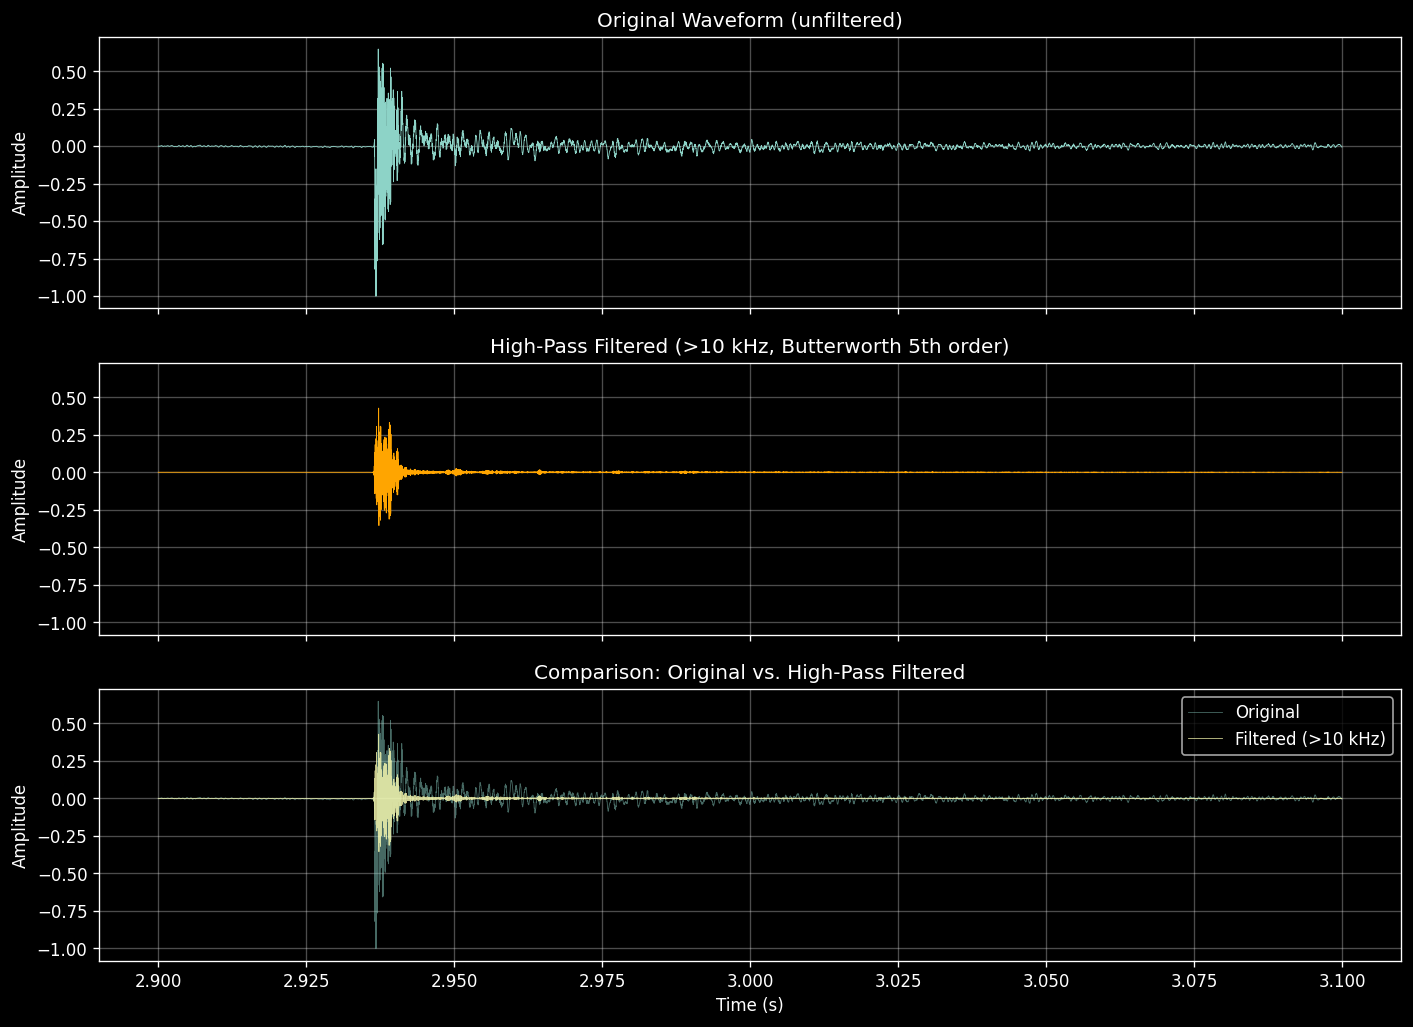

In [19]:
# Apply high-pass filter
waveform_hp = audio_utils.highpass_filter(waveform, sr, cutoff=10_000, order=5)

# Compare a filtered and a unfiltered waveform
t_start, t_end = 2.9, 3.1  # seconds
s_start, s_end = int(t_start * sr), int(t_end * sr)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

time = np.arange(s_start, s_end) / sr

# Original
axes[0].plot(time, waveform[s_start:s_end], linewidth=0.5)
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Original Waveform (unfiltered)')
axes[0].grid(True, alpha=0.3)
# Filtered
axes[1].plot(time, waveform_hp[s_start:s_end], linewidth=0.5, color='orange')
axes[1].set_ylim(axes[0].get_ylim())   # same y-axis as original
axes[1].set_ylabel('Amplitude')
axes[1].set_title('High-Pass Filtered (>10 kHz, Butterworth 5th order)')
axes[1].grid(True, alpha=0.3)

# Overlay
axes[2].plot(time, waveform[s_start:s_end], linewidth=0.5, alpha=0.5, label='Original')
axes[2].plot(time, waveform_hp[s_start:s_end], linewidth=0.5, alpha=0.8, label='Filtered (>10 kHz)')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Comparison: Original vs. High-Pass Filtered')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

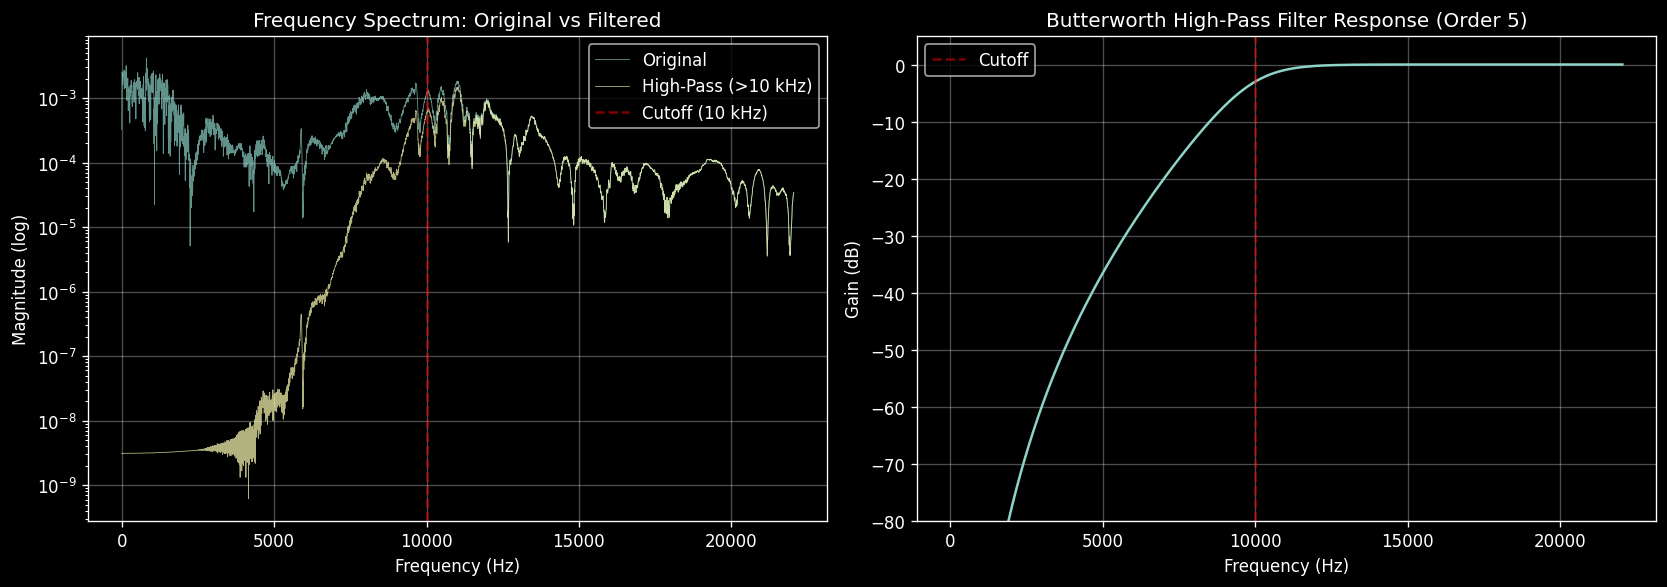

In [21]:
# Frequency domain analysis: show what the filter removes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spectrum of original
segment = waveform[s_start:s_end]
N = len(segment)
freqs = np.fft.rfftfreq(N, d=1.0/sr)
spectrum_orig = np.abs(np.fft.rfft(segment)) / N
spectrum_filt = np.abs(np.fft.rfft(waveform_hp[s_start:s_end])) / N

axes[0].semilogy(freqs, spectrum_orig, linewidth=0.5, alpha=0.7, label='Original')
axes[0].semilogy(freqs, spectrum_filt, linewidth=0.5, alpha=0.7, label='High-Pass (>10 kHz)')
axes[0].axvline(10000, color='red', linestyle='--', alpha=0.5, label='Cutoff (10 kHz)')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude (log)')
axes[0].set_title('Frequency Spectrum: Original vs Filtered')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Filter frequency response
from scipy.signal import sosfreqz,butter
sos = butter(5, 10000, btype='highpass', fs=sr, output='sos')
w, h = sosfreqz(sos, worN=8000, fs=sr)
axes[1].plot(w, 20 * np.log10(np.abs(h) + 1e-10), linewidth=1.5)
axes[1].axvline(10000, color='red', linestyle='--', alpha=0.5, label='Cutoff')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Gain (dB)')
axes[1].set_title('Butterworth High-Pass Filter Response (Order 5)')
axes[1].set_ylim(-80, 5)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Energy Based Bounce Detection
The core signal processing step: detecting ball bounces from continuous audio using **energy peak detection**

#### Algorithm (Exponential Decay Average)
1. Divide the (filtered) signal into **1 ms** non-overlapping frames
2. Compute the **mean absolute energy** per frame: $e_k=\frac{1}{N}\sum |x_i|$
3. Maintain an **exponential moving average (EMA)** of energy:
   $$\bar{E}_{k+1} = \gamma \cdot \bar{E}_k + (1 - \gamma) \cdot e_k$$
   where $\gamma = 0.9$ is the decay factor

4. A **bounce** is detected when $e_k > \theta \cdot \bar{E}_k$ (threshold multiplier $\theta = 3$)
5. A **100 ms timeout** prevents double-triggering on the same event

The high-pass filter applied beforehand ensures the energy peaks correspond to ball impacts rather than noise.

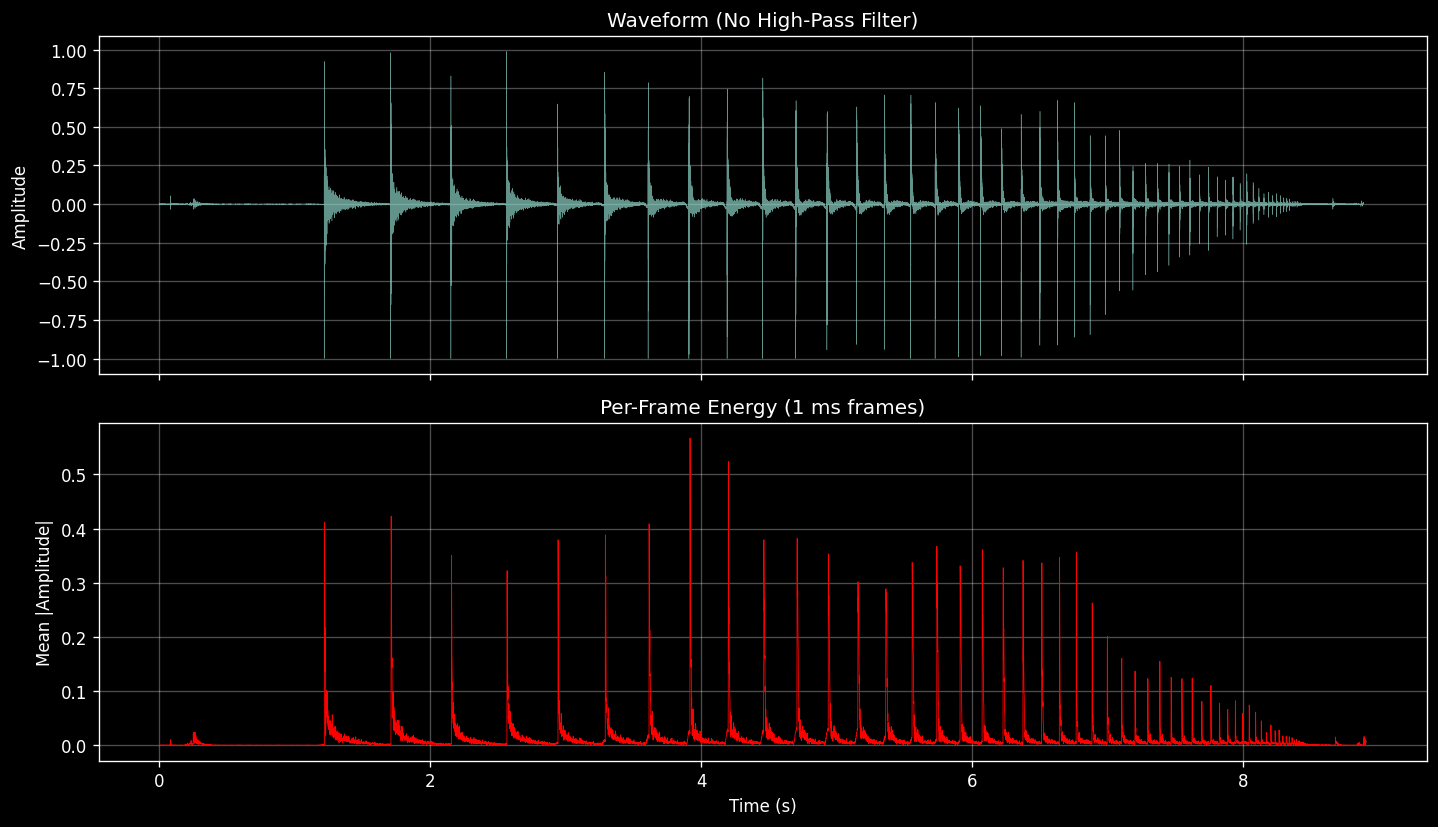

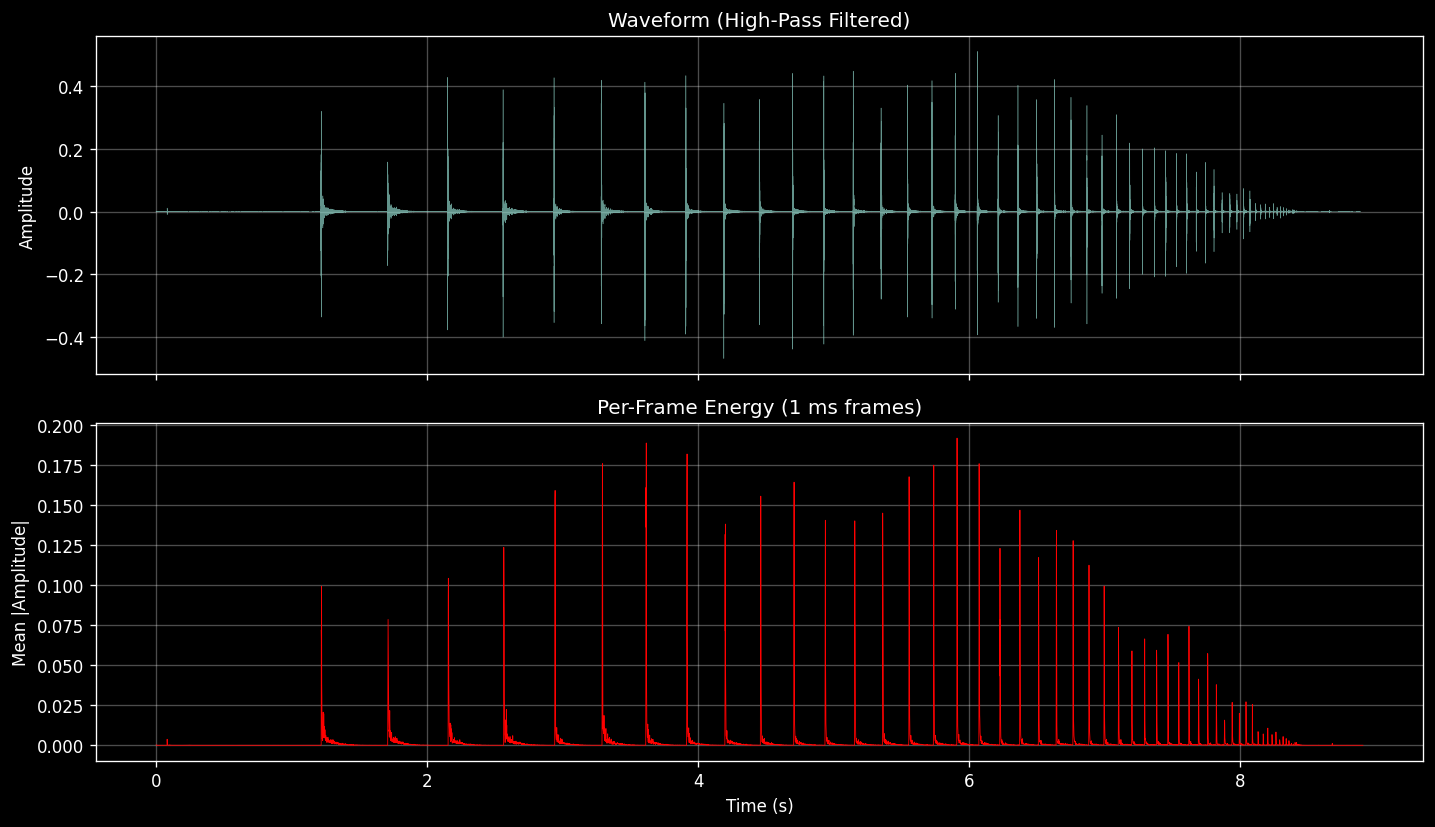

In [43]:
from src.detectors.energy_calculator import SimpleEnergyCalculator

simple_energy_calculator = SimpleEnergyCalculator()

# ---------- No high-pass ----------
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

time_full = np.arange(len(waveform)) / sr
no_hp_frame_energy = simple_energy_calculator.compute_frame_energy(
    waveform, sr, frame_ms=1.0
)
frame_time_no_hp = np.arange(len(no_hp_frame_energy)) * 1.0 / 1000.0

axes[0].plot(time_full, waveform, linewidth=0.3, alpha=0.7)
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Waveform (No High-Pass Filter)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(frame_time_no_hp, no_hp_frame_energy, linewidth=0.5, color="red")
axes[1].set_ylabel("Mean |Amplitude|")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Per-Frame Energy (1 ms frames)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ---------- High-pass ----------
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

time_full_hp = np.arange(len(waveform_hp)) / sr
hp_frame_energy = simple_energy_calculator.compute_frame_energy(
    waveform_hp, sr, frame_ms=1.0
)
frame_time_hp = np.arange(len(hp_frame_energy)) * 1.0 / 1000.0

axes[0].plot(time_full_hp, waveform_hp, linewidth=0.3, alpha=0.7)
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Waveform (High-Pass Filtered)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(frame_time_hp, hp_frame_energy, linewidth=0.5, color="red")
axes[1].set_ylabel("Mean |Amplitude|")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Per-Frame Energy (1 ms frames)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

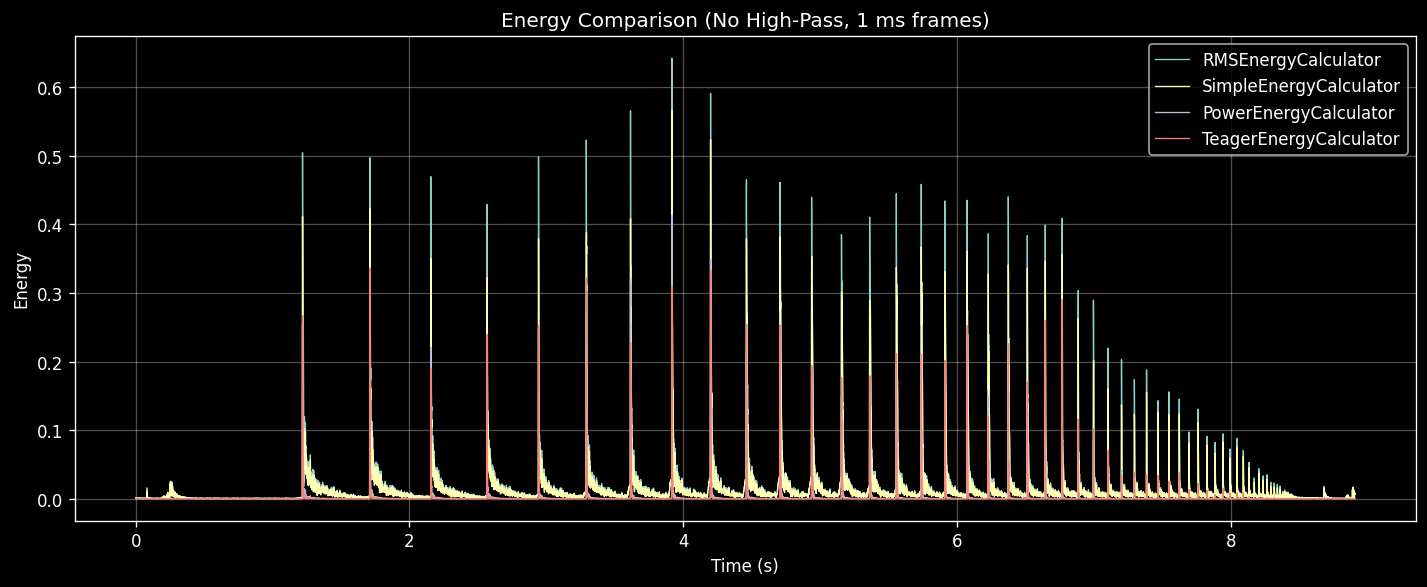

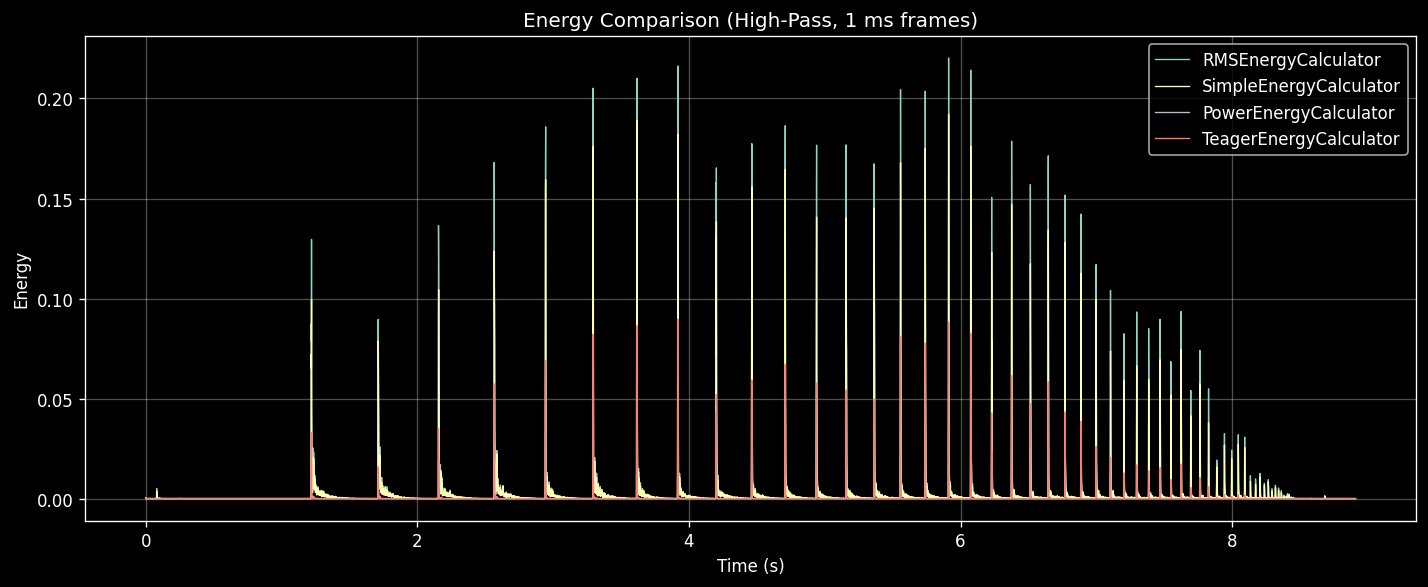

In [45]:
import src.detectors.energy_calculator as ec
import matplotlib.pyplot as plt
import numpy as np

energy_calculators = [
    ec.RMSEnergyCalculator(),
    ec.SimpleEnergyCalculator(),
    ec.PowerEnergyCalculator(),
    ec.TeagerEnergyCalculator(),
]

# ---------- No high-pass ----------
fig, ax = plt.subplots(figsize=(12, 5))

for calc in energy_calculators:
    frame_energy = calc.compute_frame_energy(waveform, sr, frame_ms=1.0)
    frame_time = np.arange(len(frame_energy)) * 1.0 / 1000.0
    ax.plot(frame_time, frame_energy, linewidth=0.8, label=calc.__class__.__name__)

ax.set_ylabel("Energy")
ax.set_xlabel("Time (s)")
ax.set_title("Energy Comparison (No High-Pass, 1 ms frames)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ---------- High-pass ----------
fig, ax = plt.subplots(figsize=(12, 5))

for calc in energy_calculators:
    frame_energy = calc.compute_frame_energy(waveform_hp, sr, frame_ms=1.0)
    frame_time = np.arange(len(frame_energy)) * 1.0 / 1000.0
    ax.plot(frame_time, frame_energy, linewidth=0.8, label=calc.__class__.__name__)

ax.set_ylabel("Energy")
ax.set_xlabel("Time (s)")
ax.set_title("Energy Comparison (High-Pass, 1 ms frames)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()